In [4]:
import time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT = Path("checkpoints"); CKPT.mkdir(exist_ok=True)
CLASSES = ["самолёт","автомобиль","птица","кошка","олень","собака","лягушка","лошадь","корабль","грузовик"]
print(device)

cuda


In [9]:
ROOT = Path("/kaggle/input/datasets/ayush1220/cifar10/cifar10")
tr = torchvision.datasets.ImageFolder(ROOT / "train", transform=torchvision.transforms.ToTensor())
te = torchvision.datasets.ImageFolder(ROOT / "test", transform=torchvision.transforms.ToTensor())
print(tr.classes, len(tr), len(te))

def load_all(ds):
    xs, ys = [], []
    for x, y in torch.utils.data.DataLoader(ds, batch_size=1000, num_workers=32): # 32 - очень важно, иначе полчаса читает файлы свои
        xs.append(x); ys.append(y)
    return torch.cat(xs), torch.cat(ys)

X, Y = load_all(tr)
Xte, Yte = load_all(te)

MEAN = X.mean((0, 2, 3), keepdim=True); STD = X.std((0, 2, 3), keepdim=True)
norm = lambda t: (t - MEAN) / STD

perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(SEED))
val_idx, tr_idx = perm[:5000], perm[5000:]
Xtr, Ytr = norm(X[tr_idx]).to(device), Y[tr_idx].to(device)
Xva, Yva = norm(X[val_idx]).to(device), Y[val_idx].to(device)
Xte_n, Yte_d = norm(Xte).to(device), Yte.to(device)
print(Xtr.shape, Xva.shape, Xte_n.shape)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] 50000 10000


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([45000, 3, 32, 32]) torch.Size([5000, 3, 32, 32]) torch.Size([10000, 3, 32, 32])


## 1. Свёртка

In [10]:
def conv2d_np(img, kernel, stride=1, padding=0):
    img = np.pad(img, padding)
    kh, kw = kernel.shape
    oh = (img.shape[0] - kh) // stride + 1
    ow = (img.shape[1] - kw) // stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            window = img[i*stride:i*stride + kh, j*stride:j*stride + kw]
            out[i, j] = (window * kernel).sum()
    return out

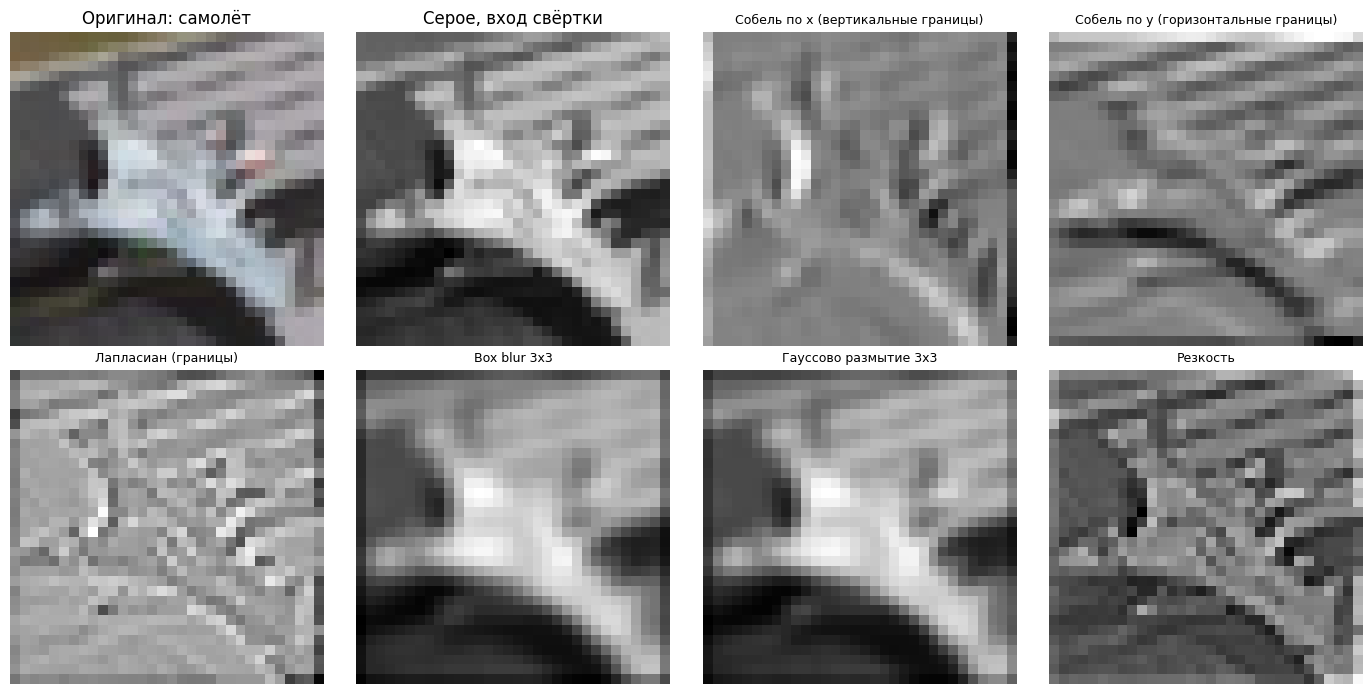

In [11]:
KERNELS = {
    "Собель по x (вертикальные границы)": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float),
    "Собель по y (горизонтальные границы)": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], float),
    "Лапласиан (границы)": np.array([[0,1,0],[1,-4,1],[0,1,0]], float),
    "Box blur 3x3": np.ones((3,3)) / 9,
    "Гауссово размытие 3x3": np.array([[1,2,1],[2,4,2],[1,2,1]], float) / 16,
    "Резкость": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], float),
}

i_img = 7
rgb = X[i_img].permute(1, 2, 0).numpy()
gray = (rgb * np.array([0.299, 0.587, 0.114])).sum(-1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
axes[0].imshow(rgb); axes[0].set_title(f"Оригинал: {CLASSES[Y[i_img]]}")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Серое, вход свёртки")
for ax, (name, k) in zip(axes[2:], KERNELS.items()):
    ax.imshow(conv2d_np(gray, k, padding=1), cmap="gray"); ax.set_title(name, fontsize=9)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

### Проверка против PyTorch

Для каждого ядра и нескольких комбинаций `stride`/`padding` считается максимум модуля разности двух результатов. Вычисления в `float64`, поэтому ожидается разность порядка 1e-13.

In [12]:
t_img = torch.tensor(gray)[None, None]
rows = []
for name, k in KERNELS.items():
    t_k = torch.tensor(k)[None, None]
    for stride, pad in [(1, 0), (1, 1), (2, 1), (2, 0)]:
        mine = conv2d_np(gray, k, stride, pad)
        ref = F.conv2d(t_img, t_k, stride=stride, padding=pad)[0, 0].numpy()
        rows.append((name, stride, pad, mine.shape, np.abs(mine - ref).max()))
cmp = pd.DataFrame(rows, columns=["ядро", "stride", "padding", "shape", "max|diff|"])
display(cmp)
assert cmp["max|diff|"].max() < 1e-9

,ядро,stride,padding,shape,max|diff|
0,Собель по x (вертикальные границы),1,0,"(30, 30)",4.440892e-16
1,Собель по x (вертикальные границы),1,1,"(32, 32)",4.440892e-16
2,Собель по x (вертикальные границы),2,1,"(16, 16)",2.220446e-16
3,Собель по x (вертикальные границы),2,0,"(15, 15)",4.440892e-16
4,Собель по y (горизонтальные границы),1,0,"(30, 30)",8.881784e-16
5,Собель по y (горизонтальные границы),1,1,"(32, 32)",8.881784e-16
6,Собель по y (горизонтальные границы),2,1,"(16, 16)",8.881784e-16
7,Собель по y (горизонтальные границы),2,0,"(15, 15)",4.440892e-16
8,Лапласиан (границы),1,0,"(30, 30)",4.440892e-16
9,Лапласиан (границы),1,1,"(32, 32)",4.440892e-16


## 2. Shape и число параметров вручную

Для свёртки с `k×k` ядром, `c_in` входными и `c_out` выходными каналами:

- выходная сторона: `⌊(n + 2·p − k) / s⌋ + 1`, где `n` — сторона входа, `p` — padding, `s` — stride. Пример: `n=32, k=3, p=1, s=1` → `(32+2−3)/1+1 = 32`; при `s=2` → `⌊31/2⌋+1 = 16`.
- параметры: `(k·k·c_in + 1)·c_out`. Каждый из `c_out` фильтров хранит `k·k·c_in` весов и один сдвиг (bias). Пример: `k=3, c_in=3, c_out=32` → `(27+1)·32 = 896`.

Линейный слой `in → out`: `(in + 1)·out`. Пулинг и ReLU параметров не имеют. BatchNorm на `c` каналах: `2c` обучаемых параметров (масштаб и сдвиг).

Ниже расчёт по формулам и сверка с реальными слоями PyTorch.

In [13]:
def out_size(n, k, s=1, p=0): return (n + 2*p - k) // s + 1
def conv_params(k, cin, cout): return (k*k*cin + 1) * cout

layers = [
    ("conv 3x3, 3->32, s1, p1",   dict(cin=3,  cout=32,  k=3, s=1, p=1), 32),
    ("conv 3x3, 32->64, s2, p1",  dict(cin=32, cout=64,  k=3, s=2, p=1), 32),
    ("conv 5x5, 64->128, s1, p0", dict(cin=64, cout=128, k=5, s=1, p=0), 16),
    ("conv 1x1, 128->10, s1, p0", dict(cin=128, cout=10, k=1, s=1, p=0), 12),
]
rows = []
for name, c, n in layers:
    m = nn.Conv2d(c["cin"], c["cout"], c["k"], c["s"], c["p"])
    real_shape = tuple(m(torch.zeros(1, c["cin"], n, n)).shape[1:])
    o = out_size(n, c["k"], c["s"], c["p"])
    rows.append((name, f"{c['cin']}x{n}x{n}", f"{c['cout']}x{o}x{o}", conv_params(c["k"], c["cin"], c["cout"]),
                 real_shape == (c["cout"], o, o), sum(p.numel() for p in m.parameters())))
display(pd.DataFrame(rows, columns=["слой", "вход", "выход (формула)", "параметры (формула)", "shape верен", "параметры (torch)"]))

,слой,вход,выход (формула),параметры (формула),shape верен,параметры (torch)
0,"conv 3x3, 3->32, s1, p1",3x32x32,32x32x32,896,True,896
1,"conv 3x3, 32->64, s2, p1",32x32x32,64x16x16,18496,True,18496
2,"conv 5x5, 64->128, s1, p0",64x16x16,128x12x12,204928,True,204928
3,"conv 1x1, 128->10, s1, p0",128x12x12,10x12x12,1290,True,1290


## 3. Небольшая CNN

Сеть из трёх convolution blocks. Блок состоит из свёртки `Conv → BatchNorm → ReLU`, затем второй свёртки и снижения разрешения вдвое:

- `down="pool"`: вторая свёртка со `stride=1`, затем `MaxPool2d(2)` — из каждого квадрата 2×2 берётся максимум;
- `down="stride"`: вторая свёртка со `stride=2`, пулинга нет, то есть сеть сама учит, как сжимать.

В обоих вариантах число слоёв и параметров в свёртках одинаковое, различается только способ сжатия. Каналы растут `w → 2w → 4w`, по мере того как пространственный размер падает `32 → 16 → 8 → 4`. После блоков — глобальное усреднение каждой карты признаков до одного числа (`AdaptiveAvgPool2d(1)`) и линейный классификатор.

In [14]:
def conv_bn_relu(cin, cout, k, stride=1):
    return [nn.Conv2d(cin, cout, k, stride, padding=k // 2, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]

class CNN(nn.Module):
    def __init__(self, width=32, k=3, down="pool", n_classes=10):
        super().__init__()
        chans = [3, width, 2*width, 4*width]
        blocks = []
        for cin, cout in zip(chans[:-1], chans[1:]):
            layers = conv_bn_relu(cin, cout, k)
            if down == "pool":
                layers += conv_bn_relu(cout, cout, k) + [nn.MaxPool2d(2)]
            else:
                layers += conv_bn_relu(cout, cout, k, stride=2)
            blocks.append(nn.Sequential(*layers))
        self.blocks = nn.ModuleList(blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(chans[-1], n_classes))

    def forward(self, x):
        for b in self.blocks:
            x = b(x)
        return self.head(x)

n_params = lambda m: sum(p.numel() for p in m.parameters())
print(CNN())
print(n_params(CNN(down="pool")), n_params(CNN(down="stride")))

CNN(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True

### Цикл обучения

Оптимизатор AdamW со шкалой скорости обучения OneCycle (скорость сначала растёт, потом падает до нуля). Аугментация — случайное отражение по горизонтали. После каждой эпохи считаются loss и accuracy на обучении и на валидации; чекпоинт с лучшей валидационной accuracy сохраняется на диск. Тест используется один раз на лучшем чекпоинте.

In [15]:
EPOCHS, BS = 15, 128

@torch.no_grad()
def evaluate(model, X, Y, bs=1000):
    model.eval()
    loss = correct = 0
    logits = []
    for i in range(0, len(X), bs):
        out = model(X[i:i+bs])
        loss += F.cross_entropy(out, Y[i:i+bs], reduction="sum").item()
        correct += (out.argmax(1) == Y[i:i+bs]).sum().item()
        logits.append(out)
    return loss / len(X), correct / len(X), torch.cat(logits)

def train(name, **cfg):
    set_seed()
    model = CNN(**cfg).to(device)
    steps = EPOCHS * (len(Xtr) // BS)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=4e-3, total_steps=steps)
    hist, best, t0 = [], 0, time.time()
    for ep in range(EPOCHS):
        model.train()
        p = torch.randperm(len(Xtr), device=device)
        tl = tc = 0
        for i in range(len(Xtr) // BS):
            idx = p[i*BS:(i+1)*BS]
            x, y = Xtr[idx], Ytr[idx]
            flip = torch.rand(len(x), device=device) < 0.5
            x = torch.where(flip[:, None, None, None], x.flip(3), x)
            out = model(x)
            loss = F.cross_entropy(out, y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step()
            tl += loss.item() * len(x); tc += (out.argmax(1) == y).sum().item()
        n = (len(Xtr) // BS) * BS
        vl, va, _ = evaluate(model, Xva, Yva)
        hist.append(dict(epoch=ep + 1, train_loss=tl / n, train_acc=tc / n, val_loss=vl, val_acc=va))
        if va > best:
            best = va; torch.save(model.state_dict(), CKPT / f"{name}.pt")
        print(f"{name} ep{ep+1:2d} | train {tl/n:.3f}/{tc/n:.3f} | val {vl:.3f}/{va:.3f}")
    model.load_state_dict(torch.load(CKPT / f"{name}.pt"))
    _, test_acc, _ = evaluate(model, Xte_n, Yte_d)
    summary = dict(run=name, params=n_params(model), best_val_acc=best, test_acc=test_acc, minutes=(time.time() - t0) / 60)
    return model, pd.DataFrame(hist), summary

## Эксперименты

Базовая сеть: `width=32`, `k=3`, `down="pool"`. Каждый эксперимент меняет ровно одну вещь, всё остальное (seed, данные, эпохи, оптимизатор) одинаково.

1. Способ сжатия: max pooling → strided convolution.
2. Размер ядра: `k=3` → `k=5` (шире окно, но больше параметров: `25·c_in` вместо `9·c_in` весов на фильтр).
3. Число каналов: `width=16` / `32` / `64`.

In [16]:
RUNS = {
    "base_pool_k3_w32": dict(width=32, k=3, down="pool"),
    "stride_k3_w32":    dict(width=32, k=3, down="stride"),
    "pool_k5_w32":      dict(width=32, k=5, down="pool"),
    "pool_k3_w16":      dict(width=16, k=3, down="pool"),
    "pool_k3_w64":      dict(width=64, k=3, down="pool"),
}
models, hists, summ = {}, {}, []
for name, cfg in RUNS.items():
    models[name], hists[name], s = train(name, **cfg)
    summ.append(s)

base_pool_k3_w32 ep 1 | train 1.435/0.486 | val 1.293/0.567
base_pool_k3_w32 ep 2 | train 0.993/0.647 | val 1.163/0.603
base_pool_k3_w32 ep 3 | train 0.804/0.719 | val 1.047/0.639
base_pool_k3_w32 ep 4 | train 0.683/0.762 | val 0.757/0.752
base_pool_k3_w32 ep 5 | train 0.573/0.802 | val 0.637/0.783
base_pool_k3_w32 ep 6 | train 0.499/0.827 | val 0.589/0.802
base_pool_k3_w32 ep 7 | train 0.438/0.849 | val 0.707/0.770
base_pool_k3_w32 ep 8 | train 0.387/0.867 | val 0.503/0.830
base_pool_k3_w32 ep 9 | train 0.339/0.882 | val 0.509/0.825
base_pool_k3_w32 ep10 | train 0.286/0.902 | val 0.517/0.835
base_pool_k3_w32 ep11 | train 0.235/0.921 | val 0.417/0.866
base_pool_k3_w32 ep12 | train 0.185/0.938 | val 0.402/0.871
base_pool_k3_w32 ep13 | train 0.146/0.953 | val 0.389/0.876
base_pool_k3_w32 ep14 | train 0.121/0.964 | val 0.387/0.878
base_pool_k3_w32 ep15 | train 0.107/0.970 | val 0.385/0.879
stride_k3_w32 ep 1 | train 1.593/0.430 | val 1.426/0.474
stride_k3_w32 ep 2 | train 1.115/0.603 | va

In [17]:
results = pd.DataFrame(summ).set_index("run")
display(results.style.format({"best_val_acc": "{:.4f}", "test_acc": "{:.4f}", "minutes": "{:.1f}"}))

,params,best_val_acc,test_acc,minutes
run,,,,
base_pool_k3_w32,288746,0.8788,0.8755,1.4
stride_k3_w32,288746,0.8454,0.8420,0.9
pool_k5_w32,798186,0.8874,0.8754,2.7
pool_k3_w16,72954,0.8284,0.8342,0.8
pool_k3_w64,1148874,0.8966,0.8952,2.4


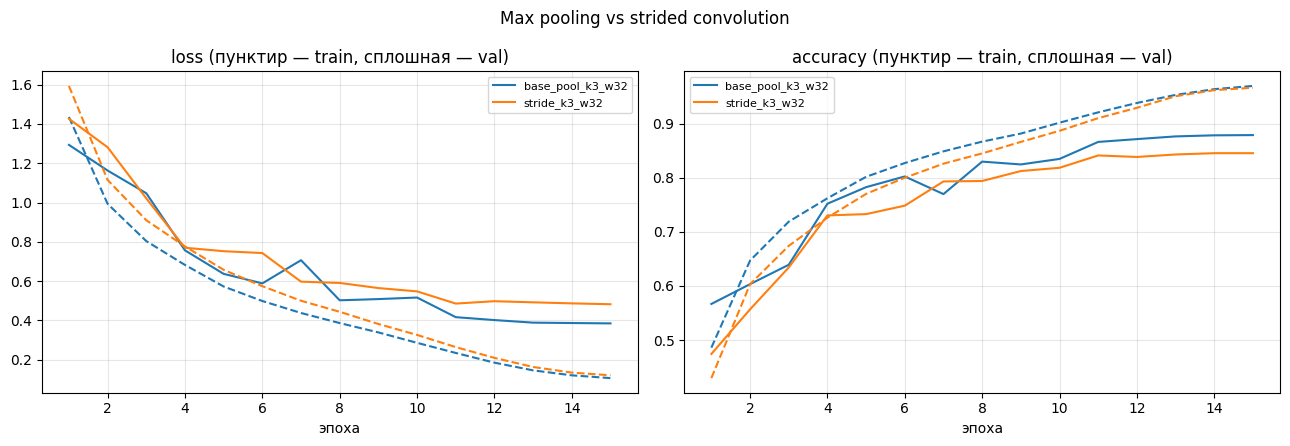

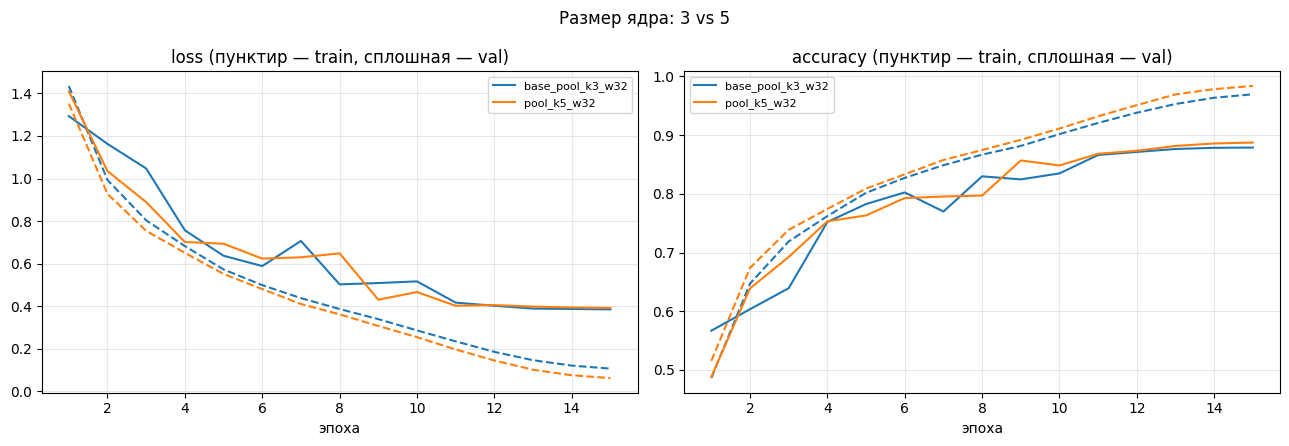

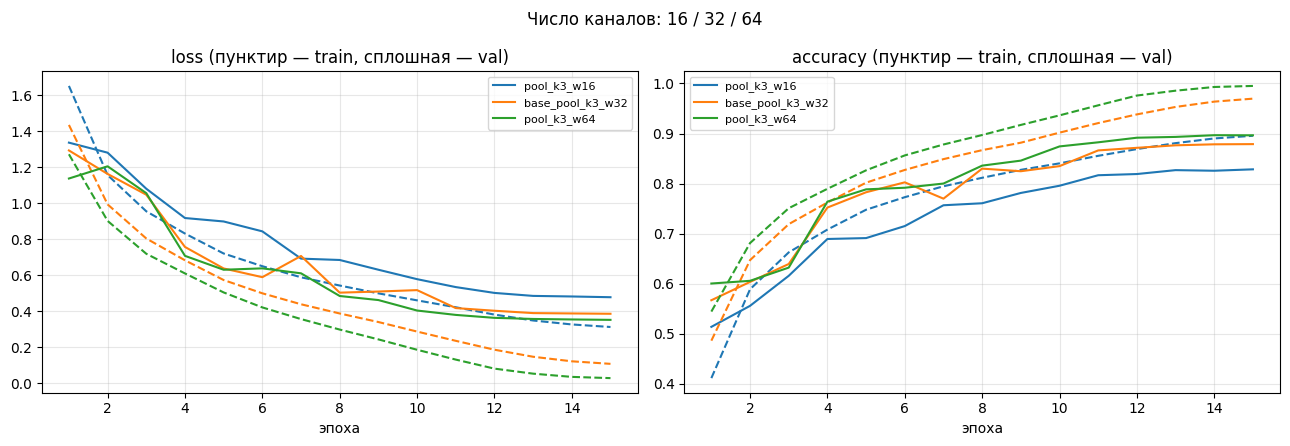

In [18]:
def plot_runs(names, title):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for i, n in enumerate(names):
        c = f"C{i}"; h = hists[n]
        ax[0].plot(h.epoch, h.train_loss, c, ls="--"); ax[0].plot(h.epoch, h.val_loss, c, label=n)
        ax[1].plot(h.epoch, h.train_acc, c, ls="--"); ax[1].plot(h.epoch, h.val_acc, c, label=n)
    ax[0].set_title("loss (пунктир — train, сплошная — val)"); ax[1].set_title("accuracy (пунктир — train, сплошная — val)")
    for a in ax: a.set_xlabel("эпоха"); a.grid(alpha=.3); a.legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_runs(["base_pool_k3_w32", "stride_k3_w32"], "Max pooling vs strided convolution")
plot_runs(["base_pool_k3_w32", "pool_k5_w32"], "Размер ядра: 3 vs 5")
plot_runs(["pool_k3_w16", "base_pool_k3_w32", "pool_k3_w64"], "Число каналов: 16 / 32 / 64")

## 4. Интерпретация

Дальше работаем с моделью, у которой лучшая валидационная accuracy.

In [19]:
best_name = results.best_val_acc.idxmax()
model = models[best_name].eval()
print(best_name, results.loc[best_name].to_dict())
denorm = lambda x: (x.cpu() * STD[0] + MEAN[0]).clamp(0, 1).permute(1, 2, 0).numpy()

pool_k3_w64 {'params': 1148874.0, 'best_val_acc': 0.8966, 'test_acc': 0.8952, 'minutes': 2.435189207394918}


### Фильтры первого слоя

Каждый фильтр первой свёртки — это ядро `k×k×3`, которое можно показать как маленькую цветную картинку: что в окне вызывает сильный отклик.

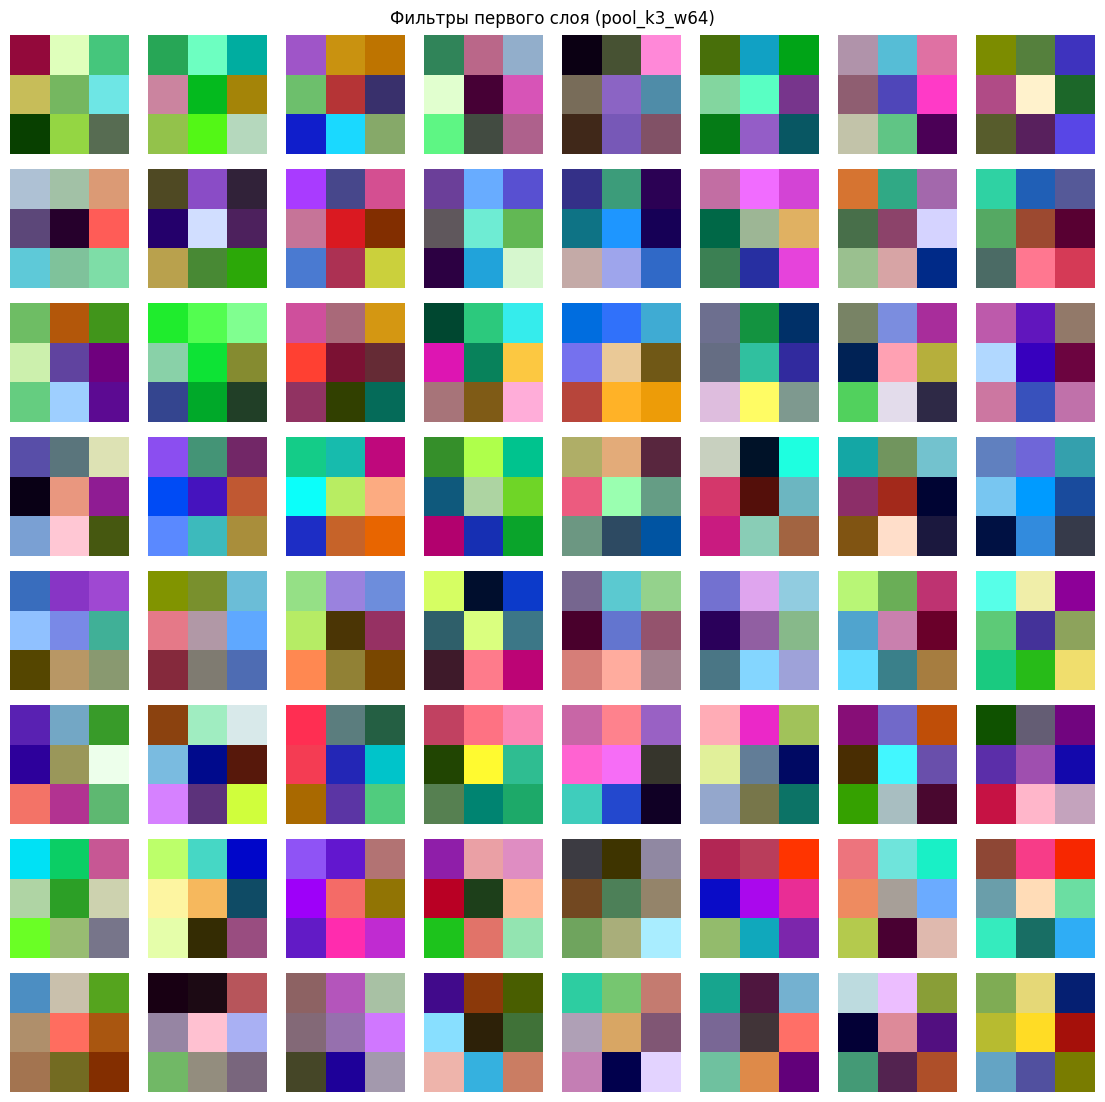

In [20]:
W = model.blocks[0][0].weight.detach().cpu()
W = (W - W.amin((1, 2, 3), keepdim=True)) / (W.amax((1, 2, 3), keepdim=True) - W.amin((1, 2, 3), keepdim=True))
cols = 8
fig, axes = plt.subplots(len(W) // cols, cols, figsize=(cols * 1.4, len(W) // cols * 1.4))
for ax, w in zip(axes.ravel(), W):
    ax.imshow(w.permute(1, 2, 0)); ax.axis("off")
plt.suptitle(f"Фильтры первого слоя ({best_name})"); plt.tight_layout(); plt.show()

### Feature maps

Карта признаков — выход одного канала свёртки: яркие места там, где фильтр нашёл «свой» узор. Показаны первые 8 каналов после первого и после второго блока (разрешение 16×16 и 8×8).

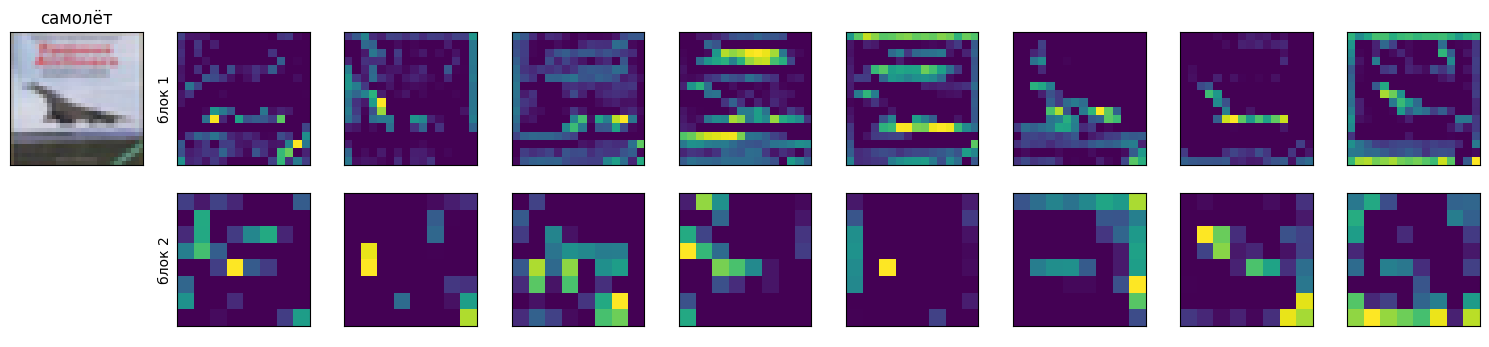

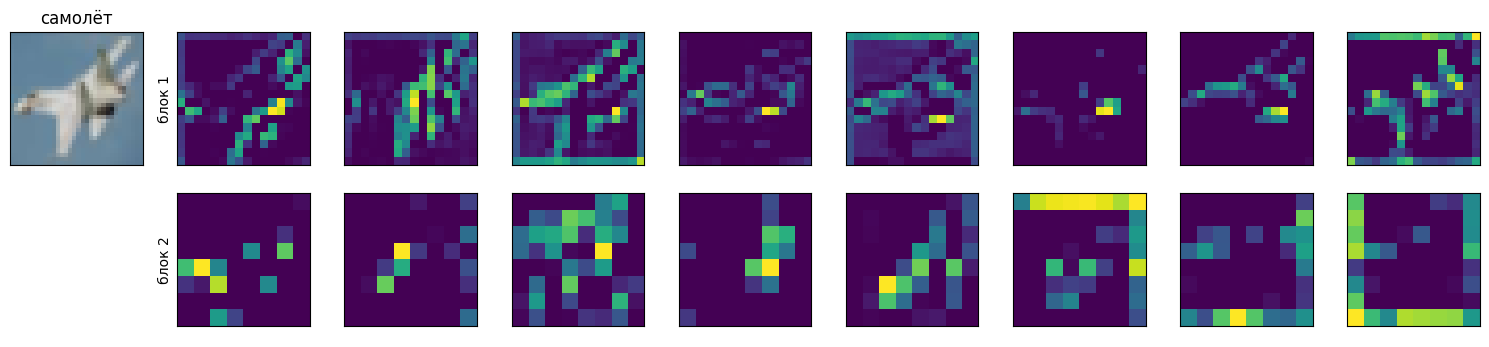

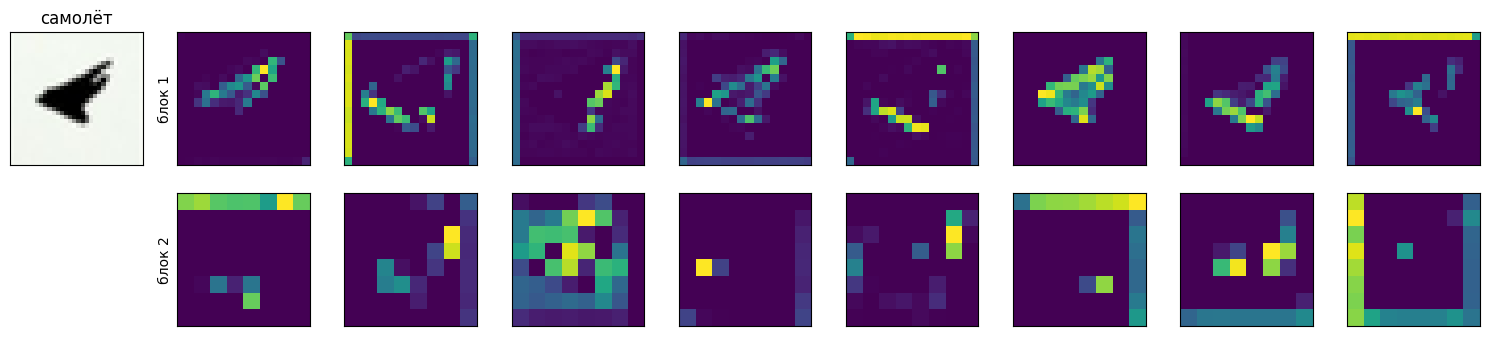

In [21]:
@torch.no_grad()
def block_outputs(x):
    outs = []
    for b in model.blocks:
        x = b(x); outs.append(x[0].cpu())
    return outs

for i in [0, 1, 2]:
    x = Xte_n[i:i+1]
    o = block_outputs(x)
    fig, axes = plt.subplots(2, 9, figsize=(15, 3.6))
    axes[0, 0].imshow(denorm(x[0])); axes[0, 0].set_title(CLASSES[Yte[i]])
    axes[1, 0].axis("off")
    for r, f in enumerate(o[:2]):
        for c in range(8):
            axes[r, c + 1].imshow(f[c], cmap="viridis")
        axes[r, 1].set_ylabel(f"блок {r+1}")
    for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

### Уверенные правильные ответы и уверенные ошибки

Уверенность — максимальная вероятность после softmax. Уверенная ошибка — картинка, где модель дала высокую вероятность неверному классу.

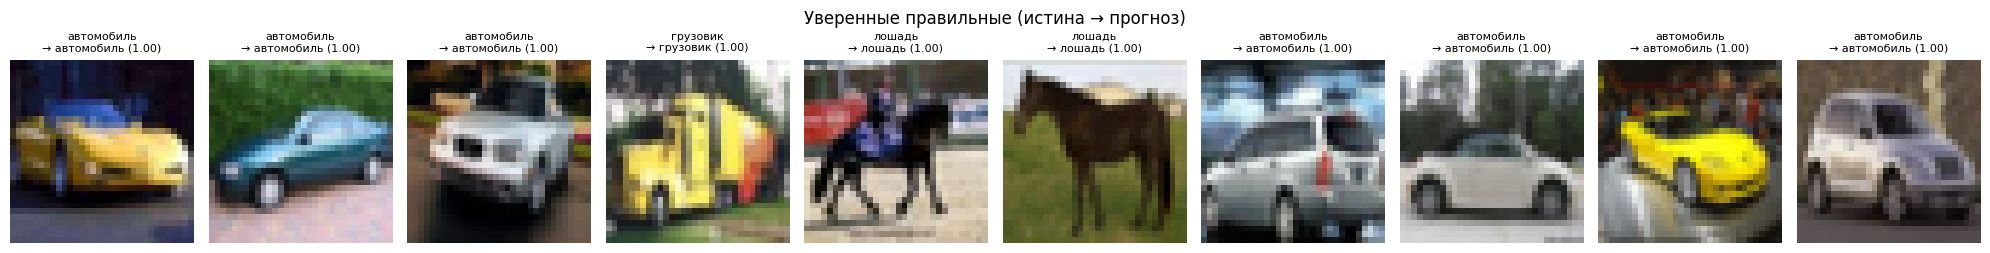

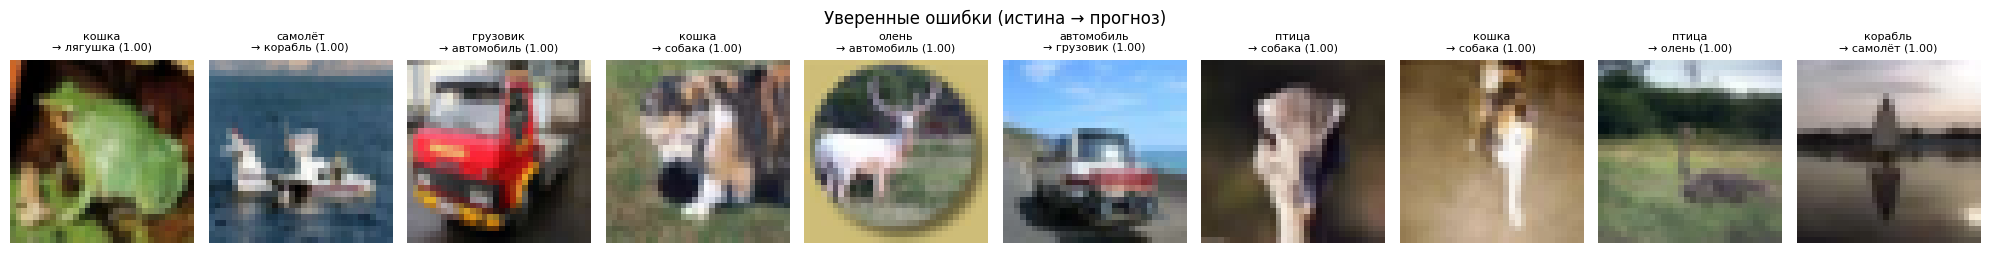

In [22]:
_, _, logits = evaluate(model, Xte_n, Yte_d)
probs = logits.softmax(1).cpu()
conf, pred = probs.max(1)
ok = pred == Yte
def show(idx, title):
    fig, axes = plt.subplots(1, len(idx), figsize=(2 * len(idx), 2.6))
    for a, i in zip(axes, idx):
        a.imshow(denorm(Xte_n[i])); a.axis("off")
        a.set_title(f"{CLASSES[Yte[i]]}\n→ {CLASSES[pred[i]]} ({conf[i]:.2f})", fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

order = conf.argsort(descending=True)
show(order[ok[order]][:10].tolist(), "Уверенные правильные (истина → прогноз)")
show(order[~ok[order]][:10].tolist(), "Уверенные ошибки (истина → прогноз)")

,accuracy
кошка,0.786
птица,0.828
собака,0.847
олень,0.904
лягушка,0.914
самолёт,0.922
лошадь,0.925
грузовик,0.931
корабль,0.943
автомобиль,0.952


кошка → собака: 95
собака → кошка: 88
грузовик → автомобиль: 38
птица → собака: 35
птица → олень: 35
птица → самолёт: 35
кошка → птица: 34
птица → кошка: 33


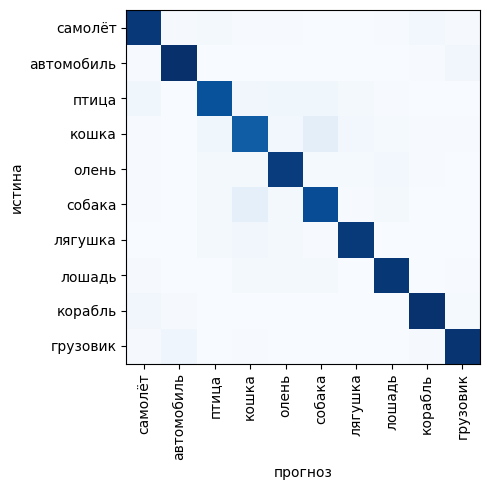

In [23]:
cm = torch.zeros(10, 10, dtype=int)
for t, p in zip(Yte, pred): cm[t, p] += 1
per_class = pd.Series((cm.diag() / cm.sum(1)).numpy(), index=CLASSES).sort_values()
display(per_class.to_frame("accuracy").style.format("{:.3f}"))

off = cm.clone(); off.fill_diagonal_(0)
top = off.flatten().argsort(descending=True)[:8]
for t in top: print(f"{CLASSES[t // 10]} → {CLASSES[t % 10]}: {off.flatten()[t].item()}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Blues"); ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=90); ax.set_yticklabels(CLASSES)
ax.set_xlabel("прогноз"); ax.set_ylabel("истина"); plt.tight_layout(); plt.show()

### Receptive field

In [24]:
def receptive_fields(m):
    r, j, rows = 1, 1, []
    for bi, b in enumerate(m.blocks):
        for l in b:
            if isinstance(l, nn.Conv2d): k, s = l.kernel_size[0], l.stride[0]
            elif isinstance(l, nn.MaxPool2d): k, s = l.kernel_size, l.stride
            else: continue
            r += (k - 1) * j; j *= s
            rows.append((f"блок {bi+1}: {type(l).__name__}", r, j))
    return pd.DataFrame(rows, columns=["слой", "receptive field, px", "шаг j, px"])

for n in ["base_pool_k3_w32", "stride_k3_w32", "pool_k5_w32"]:
    print(n, "- итоговый receptive field:", receptive_fields(models[n]).iloc[-1, 1], "из 32 px")
display(receptive_fields(model))

base_pool_k3_w32 - итоговый receptive field: 36 из 32 px
stride_k3_w32 - итоговый receptive field: 29 из 32 px
pool_k5_w32 - итоговый receptive field: 64 из 32 px


,слой,"receptive field, px","шаг j, px"
0,блок 1: Conv2d,3,1
1,блок 1: Conv2d,5,1
2,блок 1: MaxPool2d,6,2
3,блок 2: Conv2d,10,2
4,блок 2: Conv2d,14,2
5,блок 2: MaxPool2d,16,4
6,блок 3: Conv2d,24,4
7,блок 3: Conv2d,32,4
8,блок 3: MaxPool2d,36,8


## Выводы

1. Max pooling против strided convolution.

Число параметров одинаковое (288 746), различается только способ сжатия. Strided хуже на 3.3 п.п. на val и на 3.4 п.п. на test, то есть заметно больше шума.
Strided быстрее (0.9 против 1.4 мин). Вторая свёртка со stride=2 считается только в каждой второй позиции по каждой оси, то есть в четверти позиций, а в варианте с пулингом она считается во всех.
Вероятное объяснение: свёртка с шагом 2 пропускает позиции, и узкий признак, попавший между ними, ослабляется. Max pooling смотрит на отклик во всех позициях и оставляет сильнейший.
2. Размер ядра 3 → 5.

Параметров стало в 2.8 раза больше (798 186 против 288 746), время выросло в 1.9 раза. Val вырос на 0.9 п.п., что на границе шума, а test не изменился (0.8754 против 0.8755).
Вывод: ядро 5×5 здесь ничего не даёт. Параметры потрачены впустую, лучше потратить их на каналы.
3. Число каналов 16 / 32 / 64.

Test accuracy растёт монотонно: 0.8342 → 0.8755 → 0.8952, val и test согласуются между собой.
Отдача убывает. Увеличение с 16 до 32 каналов (параметры ×4) даёт +4.1 п.п., а с 32 до 64 (параметры ×4) — только +2.0 п.п.
Для сравнения: pool_k5_w32 добавила 510 тысяч параметров и не дала ничего. pool_k3_w64 добавила 860 тысяч и дала +2.0 п.п. Ширина эффективнее ядра.
4. Receptive field и разрешение.

У базовой модели receptive field 36 пикселей, у stride-модели 29, у k5-модели 64 при размере картинки 32.
Stride-модель хуже всех, и у неё же самое маленькое поле. Но совпадение не доказательство: способ сжатия поменялся одновременно. Поле 29 меньше картинки, значит, ни один нейрон последнего слоя не видит картинку целиком. Помогает то, что глобальное усреднение собирает вклад всех позиций.
Поле k5-модели в 64 пикселя вдвое больше картинки, а точность не выросла. Значит, размер поля не был узким местом базовой модели: ему уже хватало 36.
Ограничение, по-видимому, в разрешении (после трёх сжатий карта 4×4) и в ёмкости модели, на что указывает рост от ширины.